# 0017SAM — cold chain

RAMP calibration notebook. To study another client, edit the two
lines of the next cell and run everything again.

In [1]:
CLIENT = "0017SAM"
PUE_TYPE = "cold_chain"

# Study period to calibrate on (the meter file may hold more days than the
# appliance's service period; set both to None to use the whole file).
# Cut on 2025-09-15: the operator O&M register dates a second cold
# appliance on 16-17/09/2025; this calibrates the one-appliance regime
# (methodology step 12, diagnostic of 2026-08-21).
PERIOD_START = "2024-02-01"
PERIOD_END = "2025-09-15"

# Appliance rated power in W, used as a physical ceiling in the
# calibration (set to None to disable the cap).
RATED_POWER_W = 300

In [2]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO = Path.cwd().resolve().parents[1]      # notebooks/<type>/ -> repository root
sys.path.append(str(REPO / "src"))
import run

RESULTS = REPO / "resultats" / PUE_TYPE / CLIENT
FIGURES = RESULTS / "figures"


def show(*patterns):
    """Display every figure matching the given file patterns, in order."""
    for pattern in patterns:
        for path in sorted(FIGURES.glob(pattern)):
            display(Image(filename=str(path), width=900))

## Run the full chain

The next cell runs the six steps (preprocessing, clustering,
calibration, figures, summary) on this client. Progress appears
below as it happens; the whole chain takes about 10 to 15 minutes.

In [3]:
run.run(PUE_TYPE, CLIENT, period_start=PERIOD_START,
        period_end=PERIOD_END, rated_power_W=RATED_POWER_W)

[step1] 0017SAM: 515 active days kept, 32 inactive, 46 rejected, 557 outages -> resultats/cold_chain/0017SAM


[step2] 0017SAM: 2 clusters, 35 noise days, 4 seasonal targets


[step3] 0017SAM: 12 clustering figures -> resultats/cold_chain/0017SAM/figures


[step4] October: p1 25 W  p2 0.6 W  t_on 12 min  [00h-07h d=0.22, 07h-19h d=0.06, 19h-24h d=0.49]


[step5] October: cap 0.36  zero 4/6 NRMSE 0.129  act 4/6 NRMSE 0.120


[step6] October: classic  3 regions  L 32 min  tfrv 0.00  amp 1.23  rescue 8


[step7] October: fit 4/6  NRMSE 0.115+/-0.001  holdout 0.270 (floor 0.241)  amplitude partially identifiable at 15-min metering


[step8] 0017SAM: calibration figures -> resultats/cold_chain/0017SAM/figures


[step9] cold_chain: 12 client-seasons, criteria passed 49/72


## Client identity card

In [4]:
clean = pd.read_csv(RESULTS / "timeseries_clean.csv", index_col=0,
                    parse_dates=True)
daily = pd.read_csv(RESULTS / "daily_matrix_W.csv", index_col=0,
                    parse_dates=True)
kept = pd.read_csv(RESULTS / "clustered_features.csv", index_col=0)
card = pd.Series({
    "Client": CLIENT,
    "PUE type": PUE_TYPE.replace("_", " "),
    "Site": "Samionta" if CLIENT.endswith("SAM") else "Gbowele",
    "Rated power (W)": RATED_POWER_W if RATED_POWER_W else "-",
    "Study period": f"{PERIOD_START} to {PERIOD_END}",
    "Raw days with data": int(pd.Series(clean.index.normalize()).nunique()),
    "Complete days (96 slots)": len(daily),
    "Days kept after filtering": len(kept),
})
card.to_frame("value")

,value
Client,0017SAM
PUE type,cold chain
Site,Samionta
Rated power (W),300
Study period,2024-02-01 to 2025-09-15
Raw days with data,593
Complete days (96 slots),515
Days kept after filtering,515


## Measured seasonal profiles and day-by-hour heatmap and activity timeline

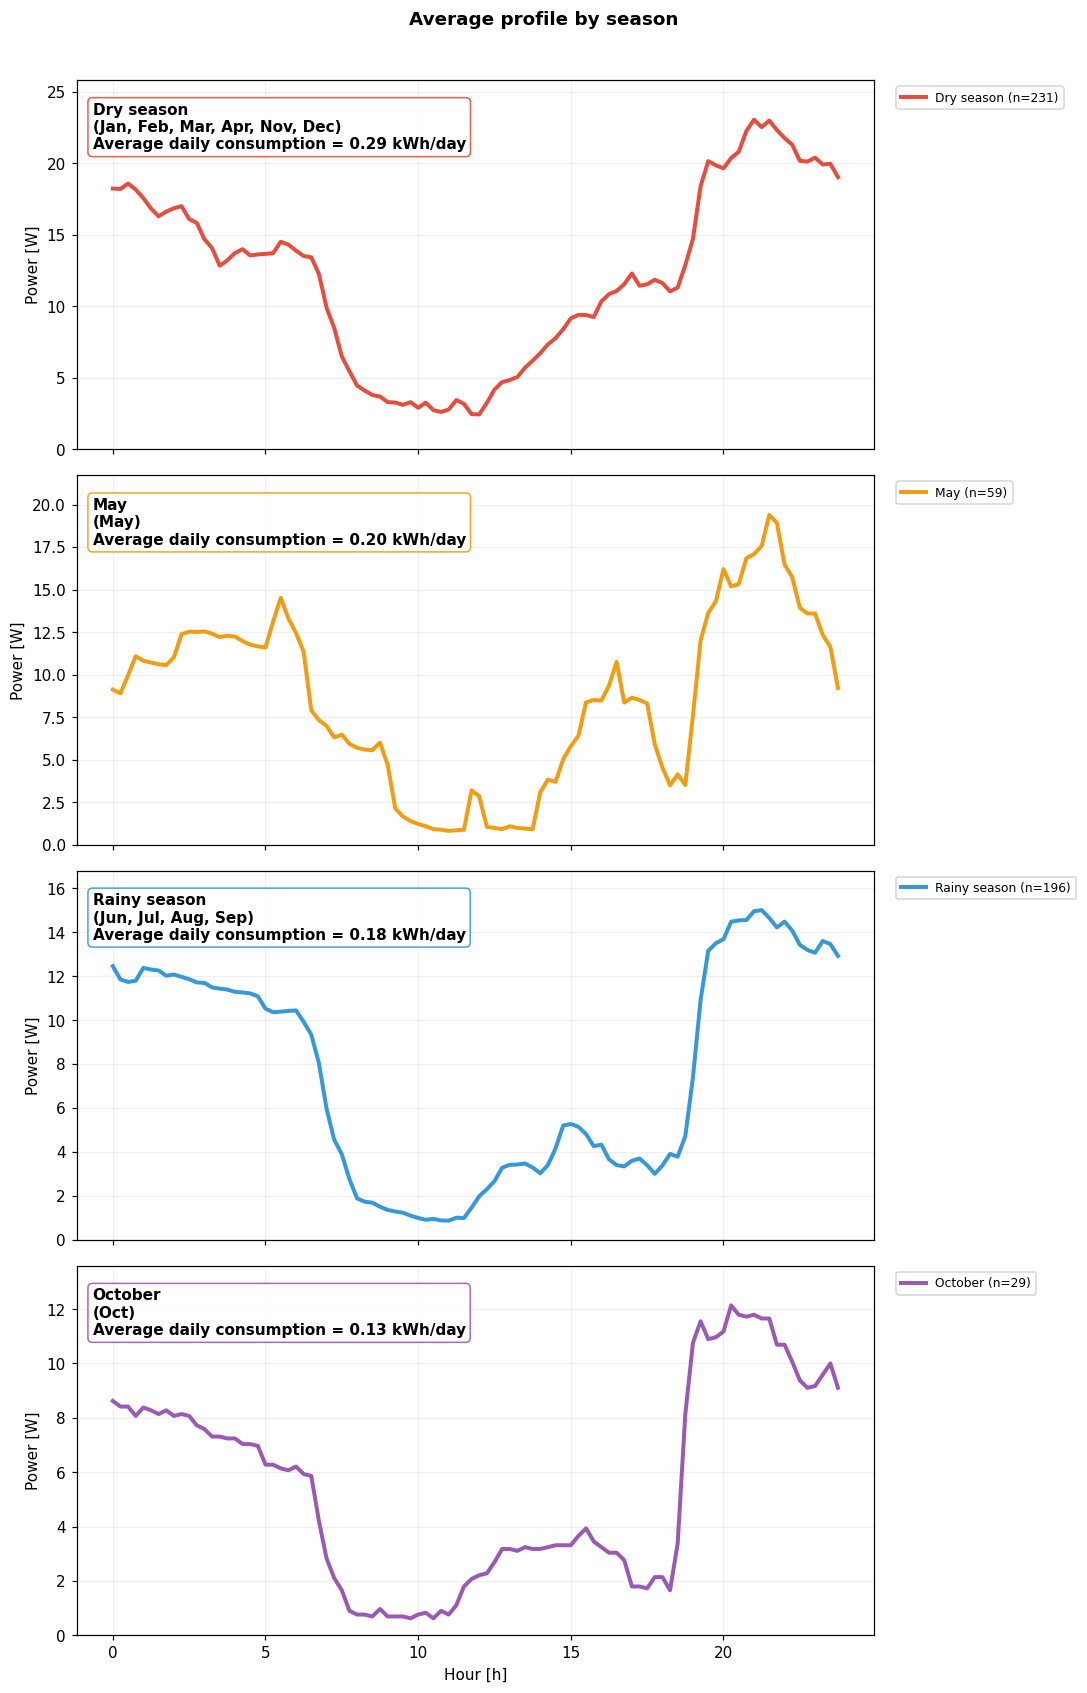

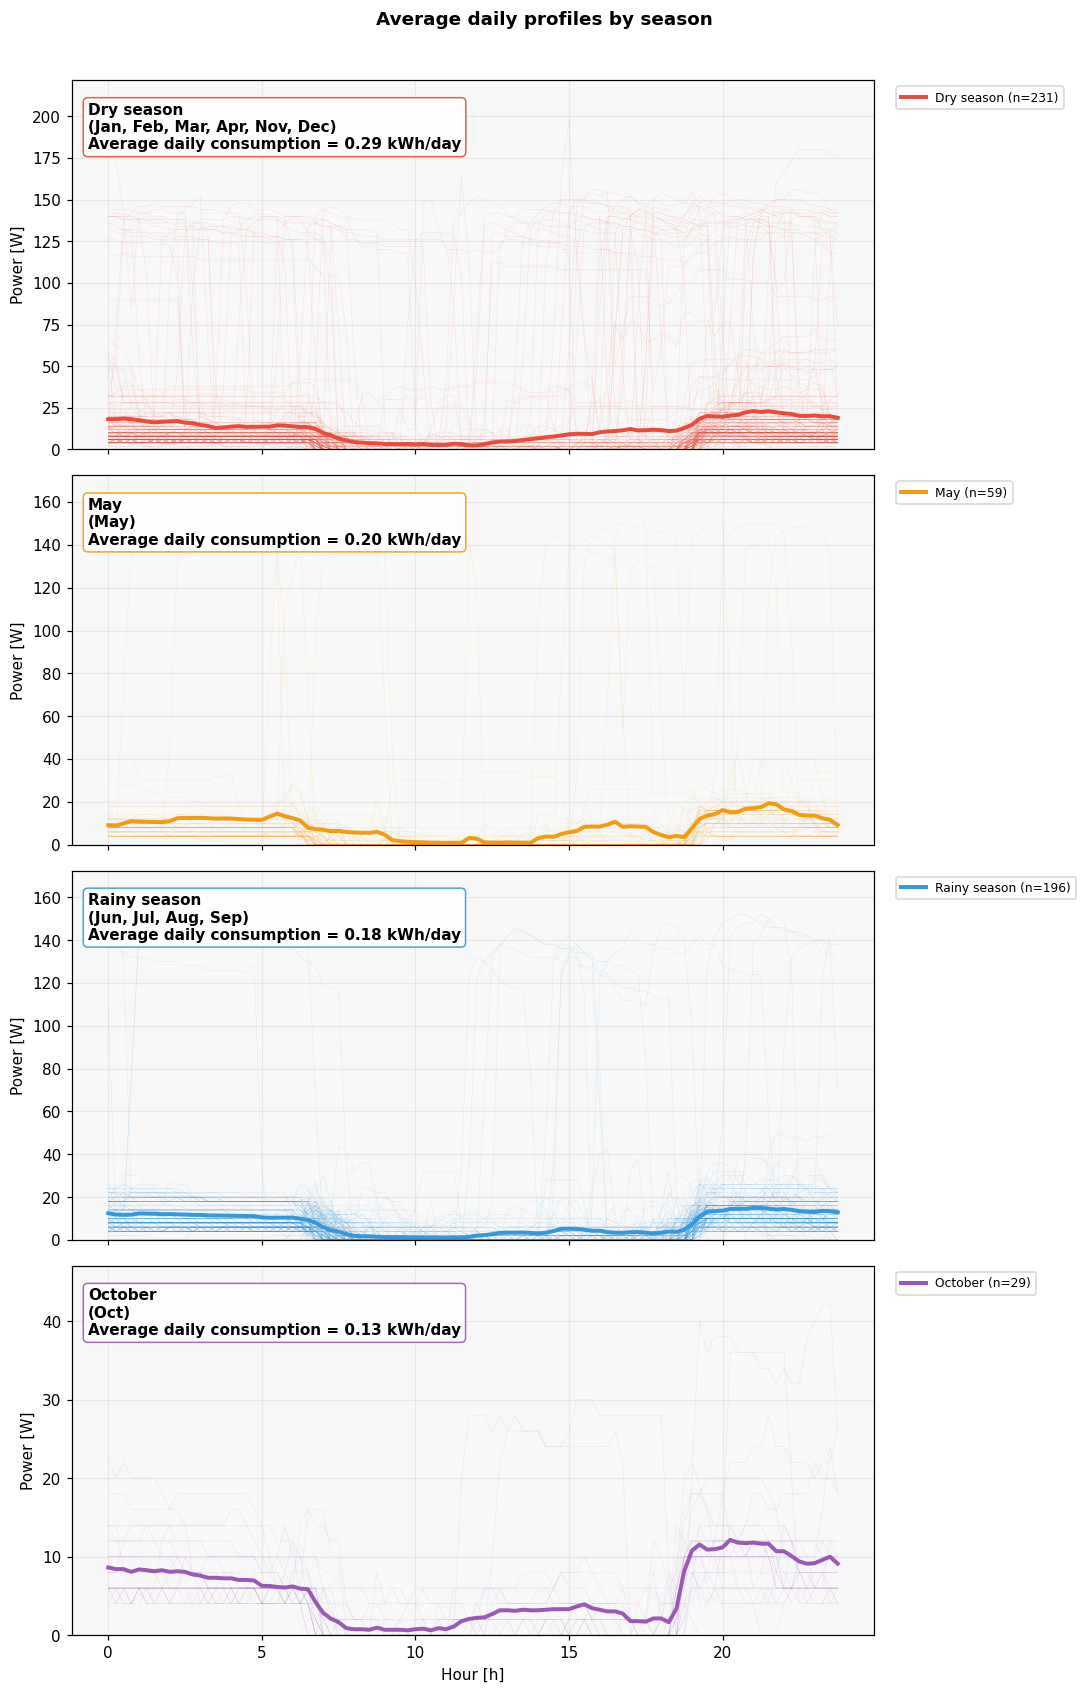

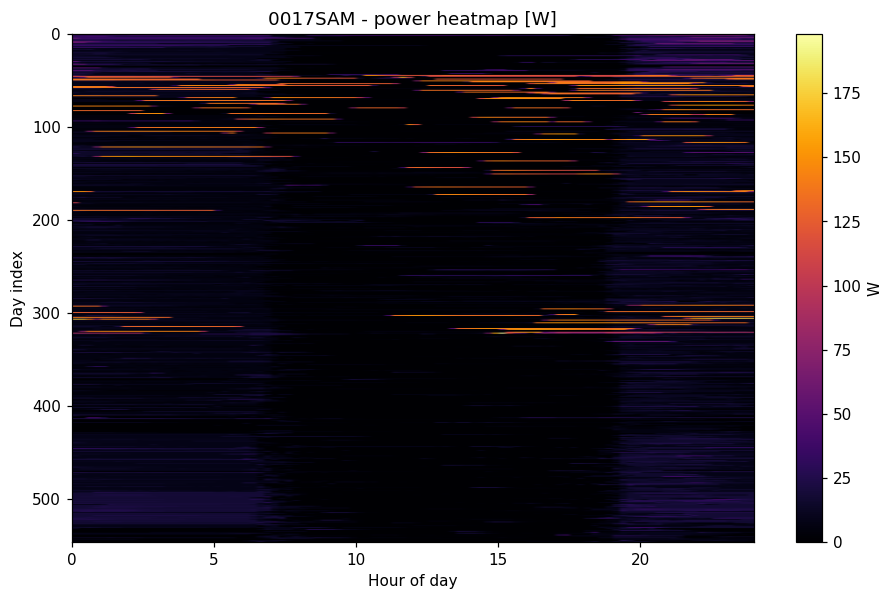

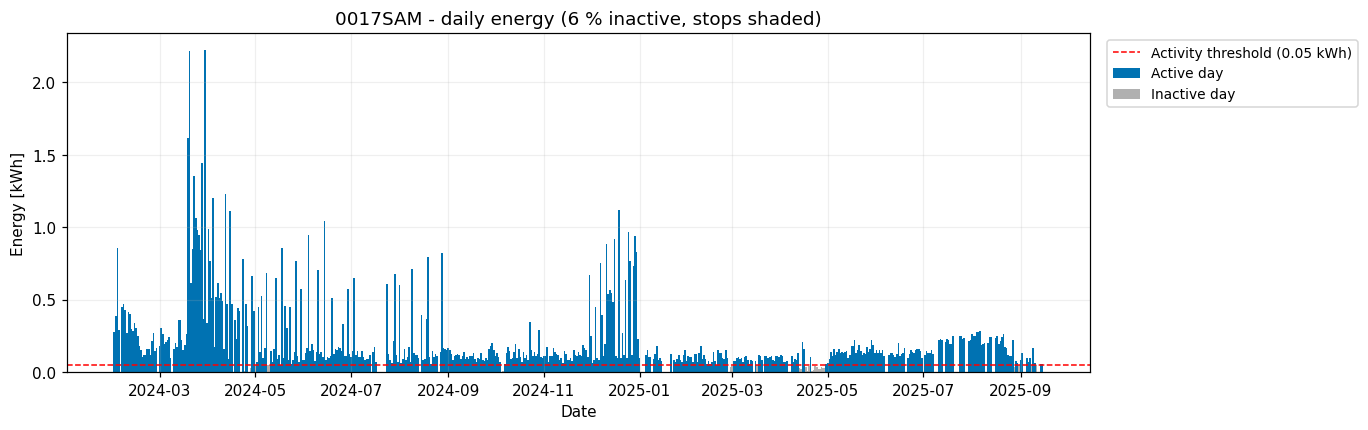

In [5]:
show("07_season_profiles.png", "07b_season_profiles_stacked.png",
     "0*_heatmap.png", "03_activity_timeline.png")

## Clustering

k-distance heuristic, cluster sizes, cluster profiles, feature
scatters and the season/cluster distribution.

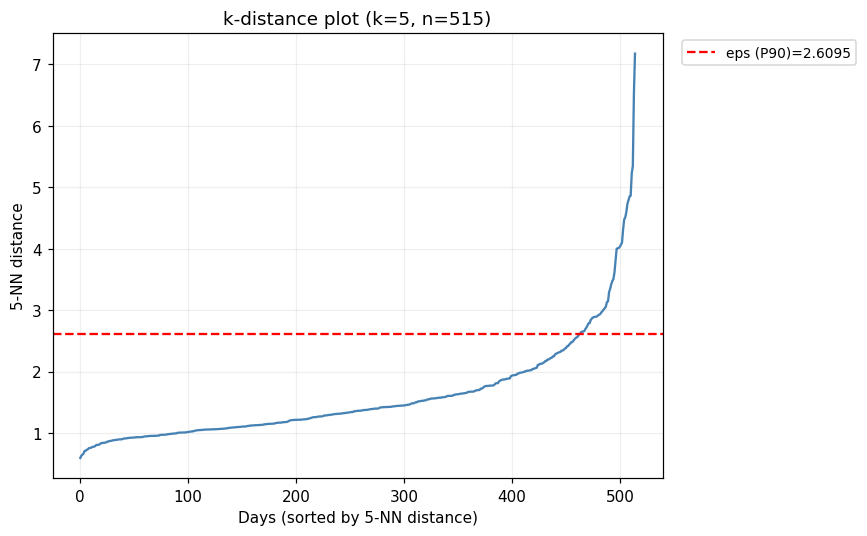

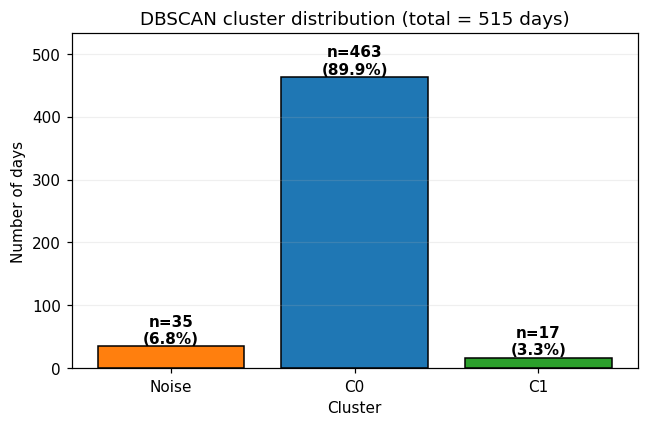

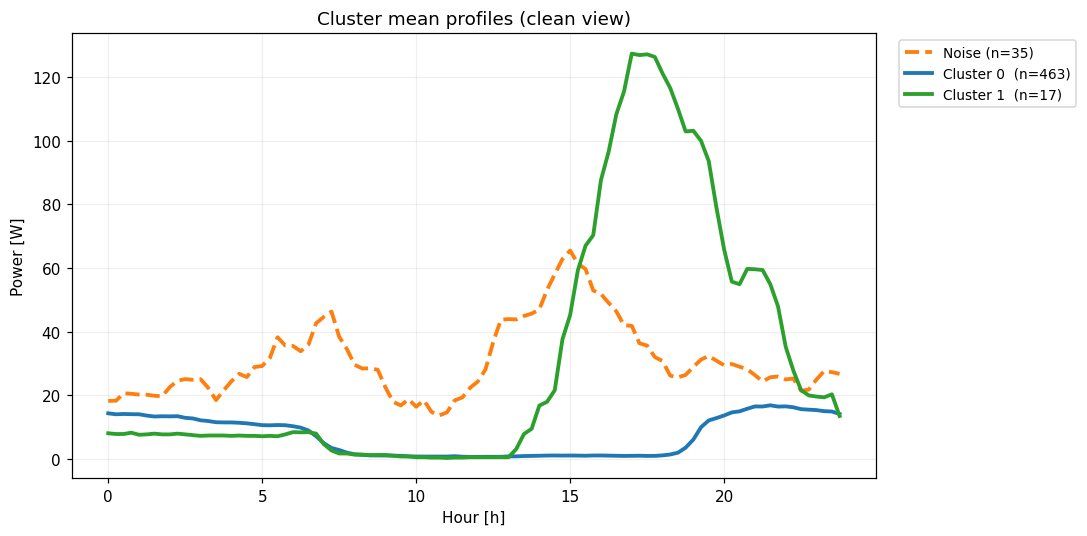

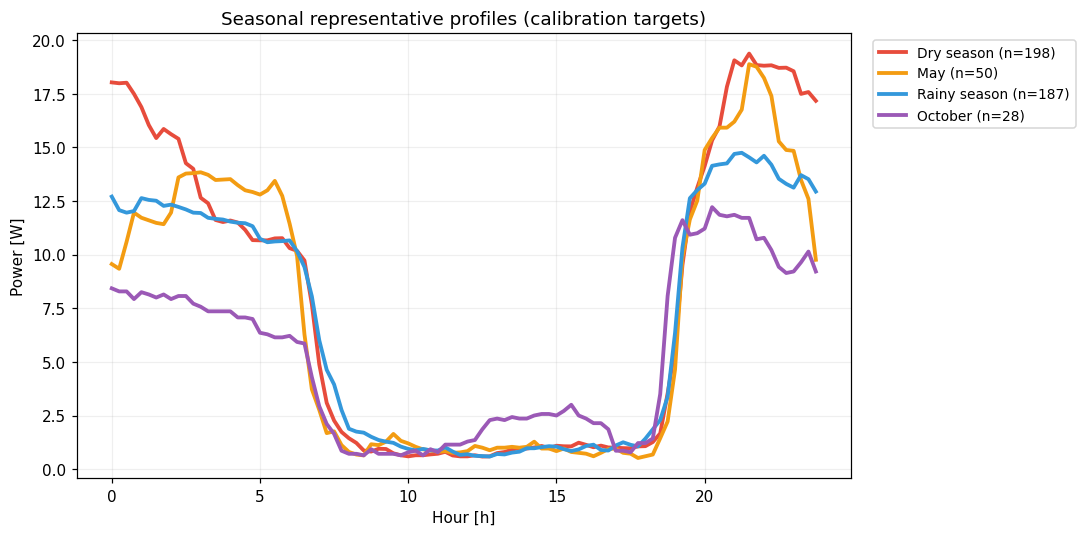

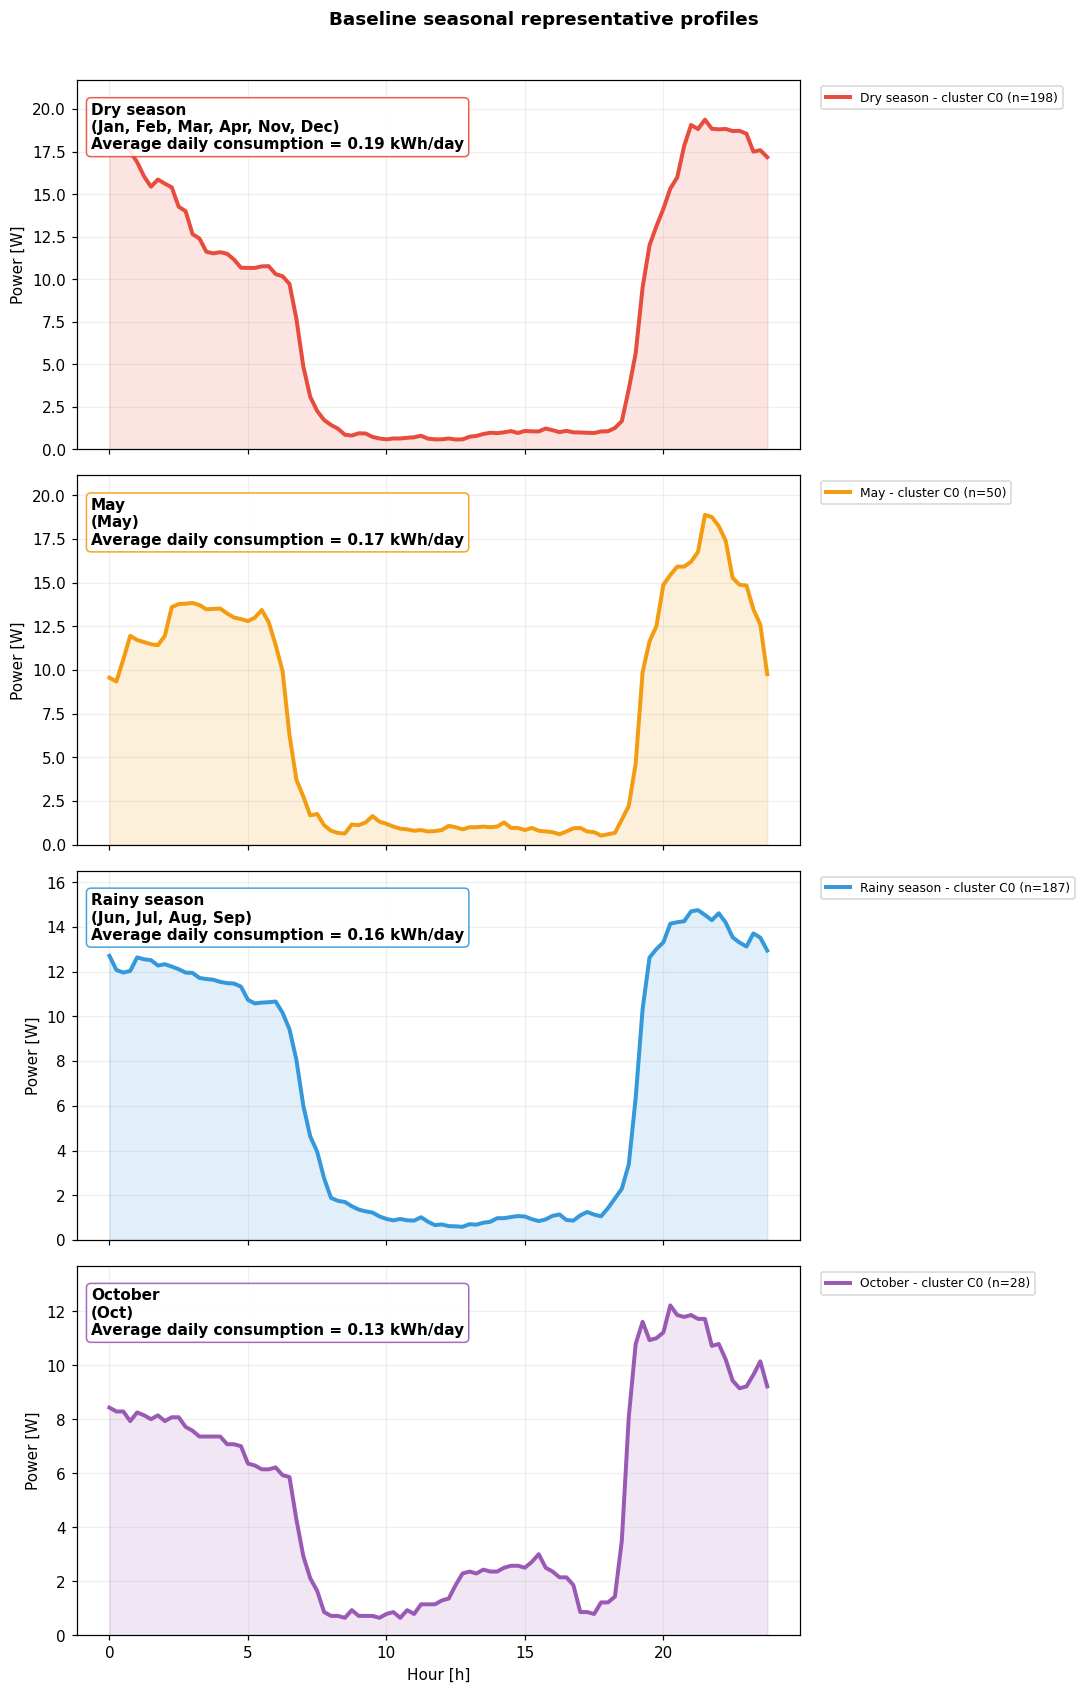

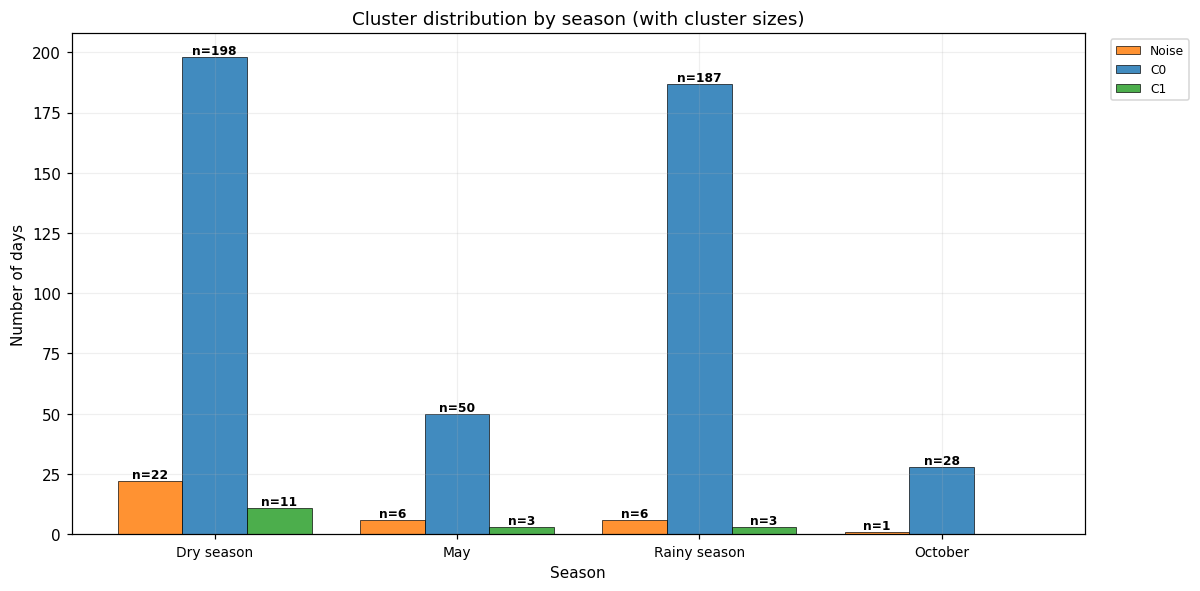

In [6]:
show("08_k_distance_plot.png", "0*_cluster_histogram.png",
     "*_cluster_profiles*.png", "*repr*.png",
     "12_scatter_E_Ppeak.png", "13_scatter_E_LF.png",
     "14_scatter_Ppeak_peakH.png", "15_season_cluster_bar.png")

## Dry season

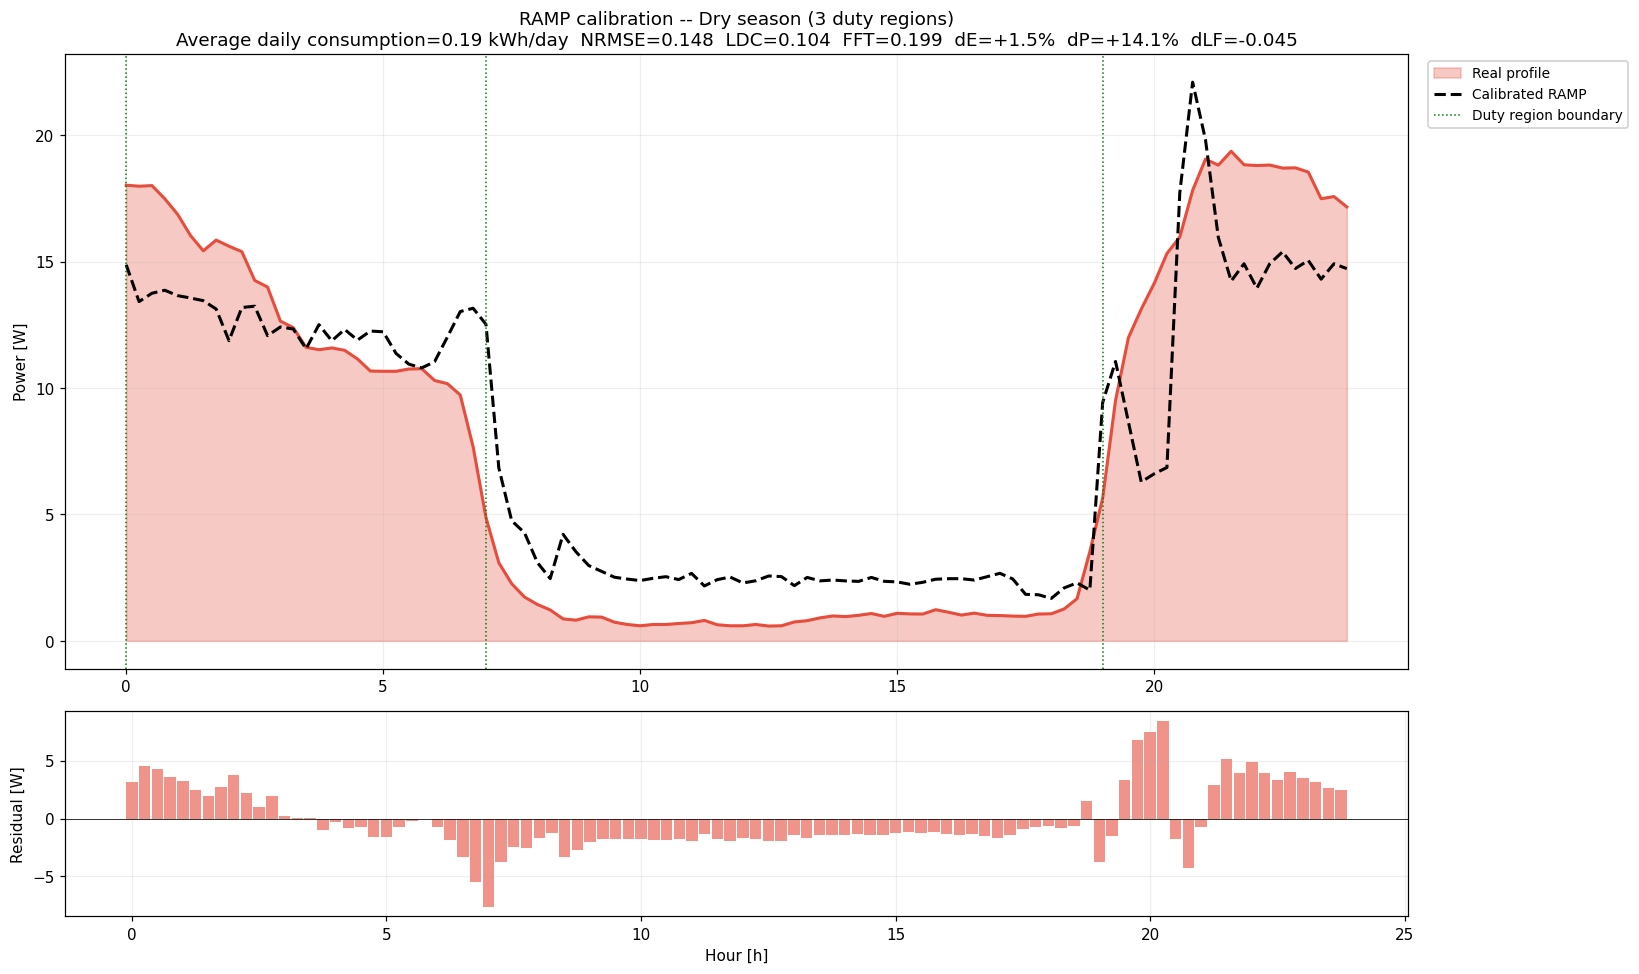

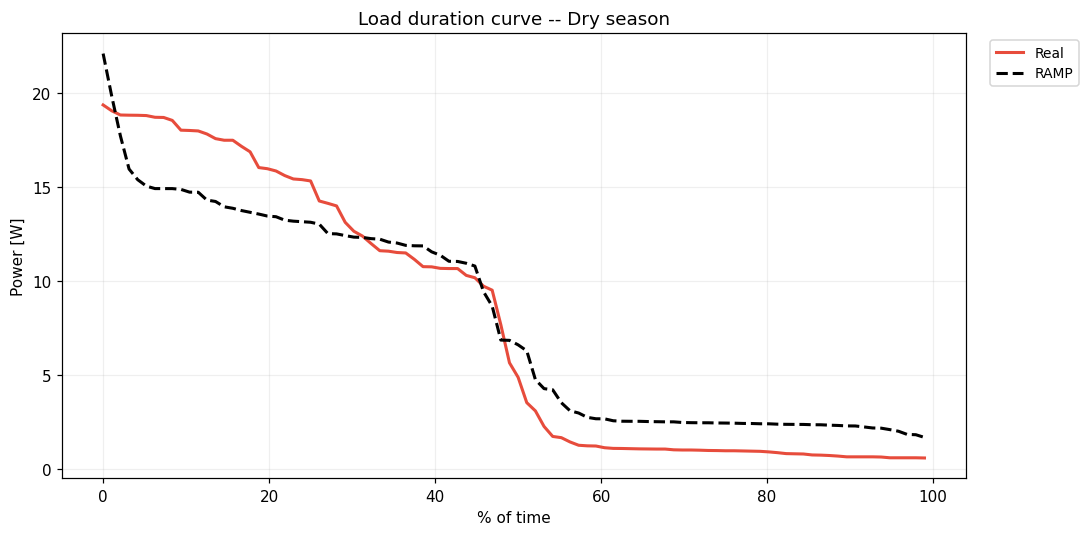

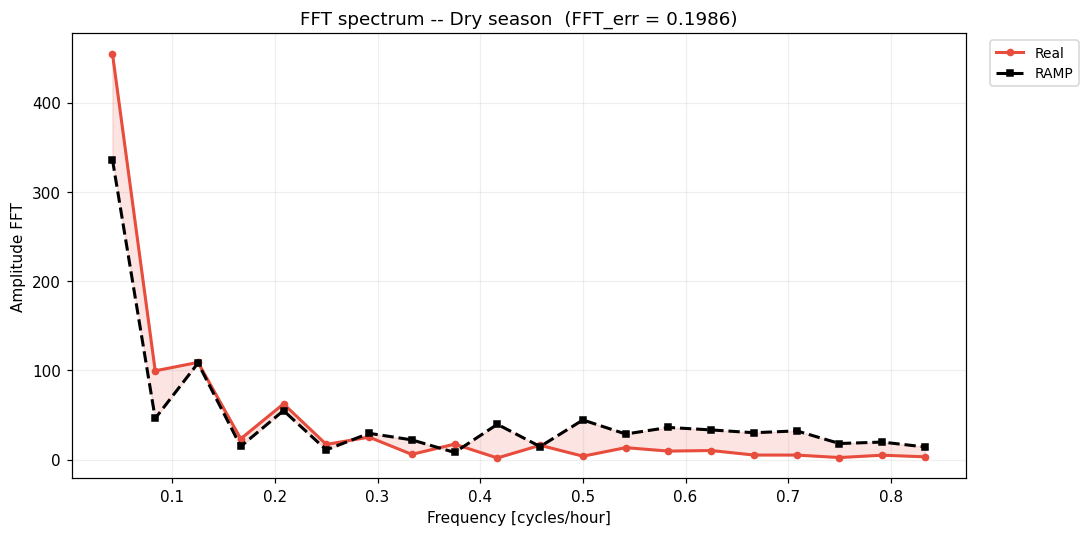

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
0,Dry season,2,0.148,0.104,0.199,1.478,14.106,-0.045


In [7]:
season = "Dry season"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_Dry_season.png", f"41_ldc_Dry_season.png", f"42_fft_Dry_season.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## May

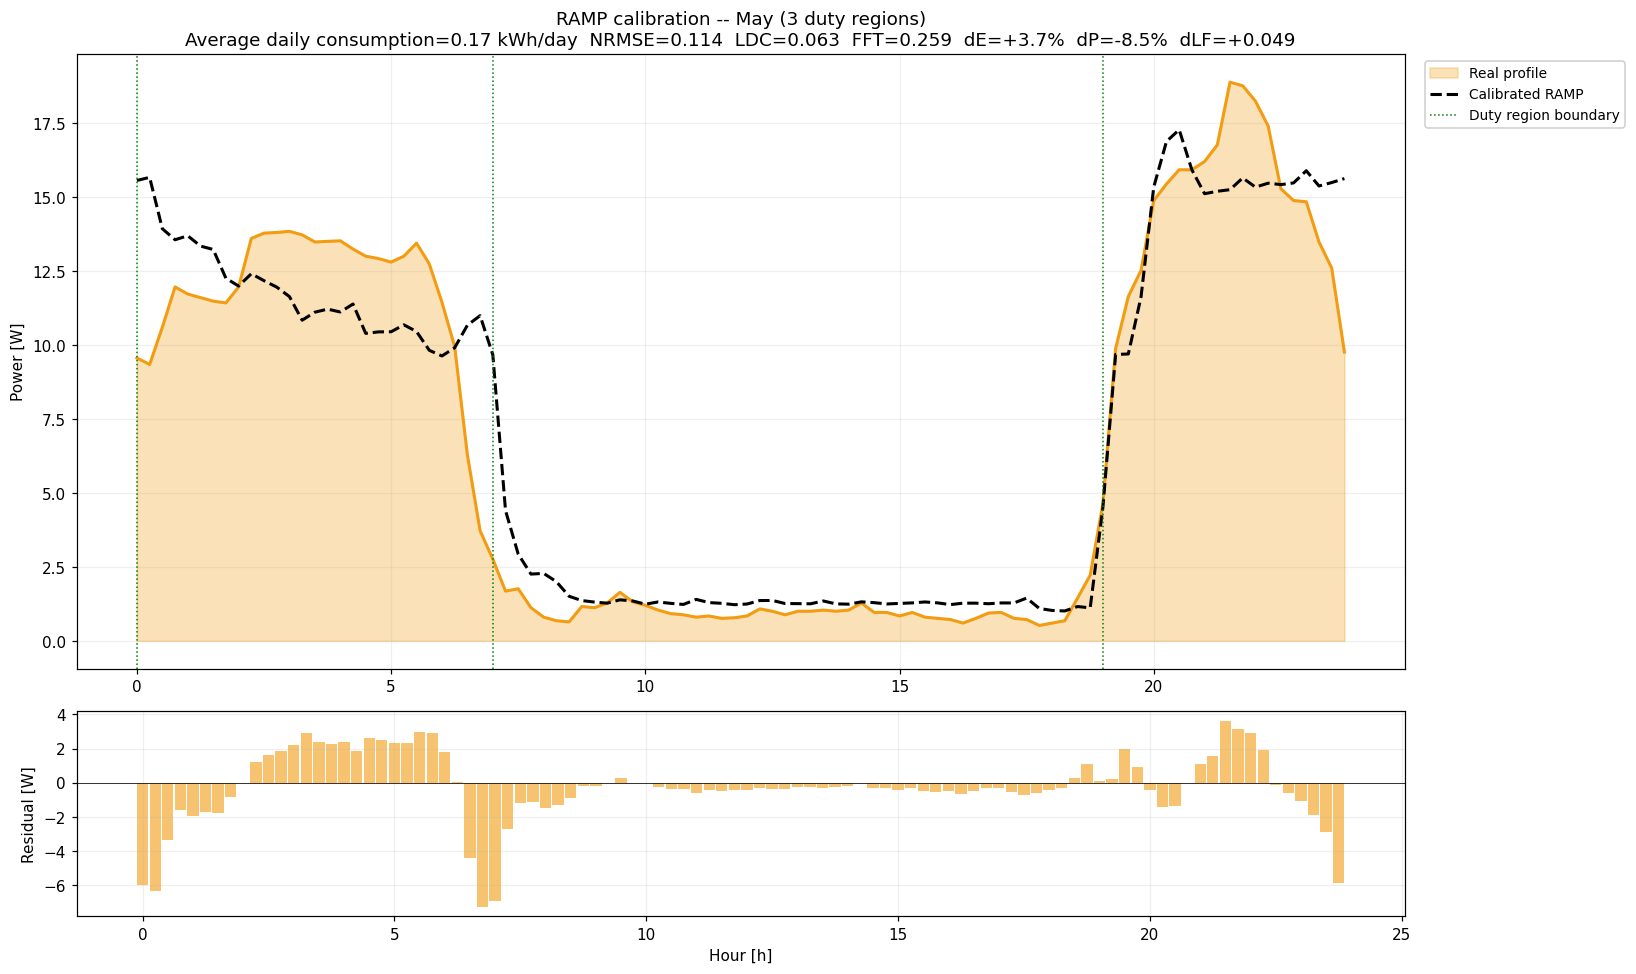

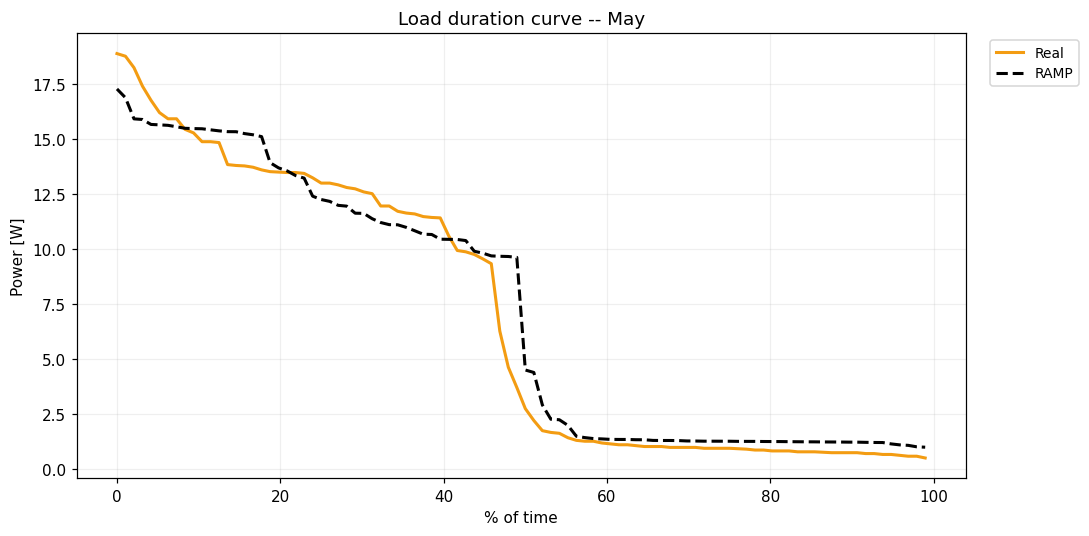

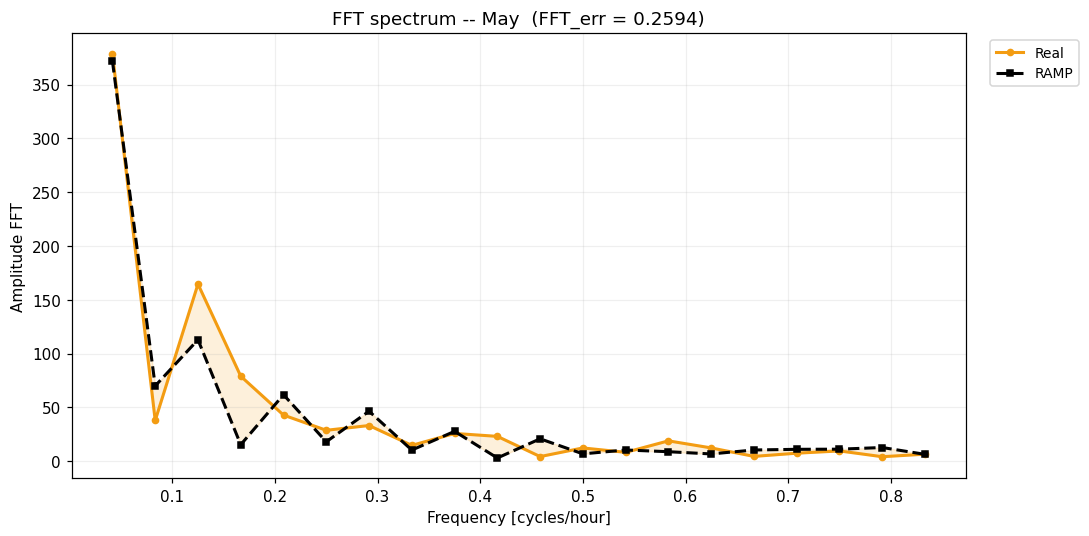

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
1,May,4,0.114,0.063,0.259,3.693,-8.508,0.049


In [8]:
season = "May"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_May.png", f"41_ldc_May.png", f"42_fft_May.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## Rainy season

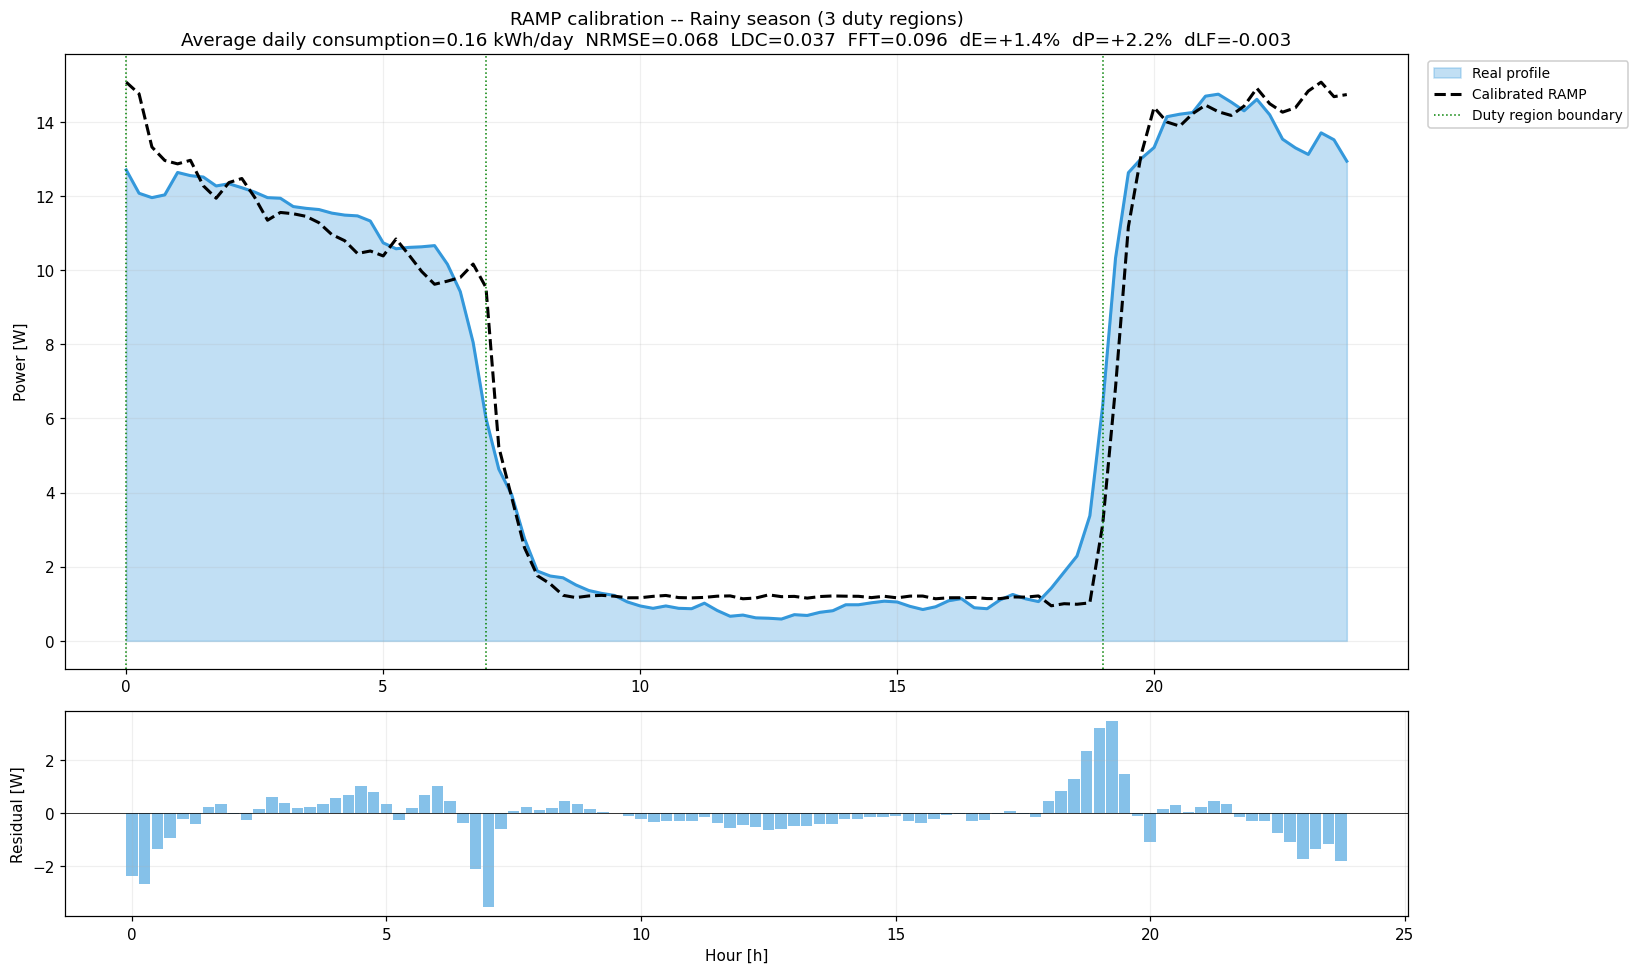

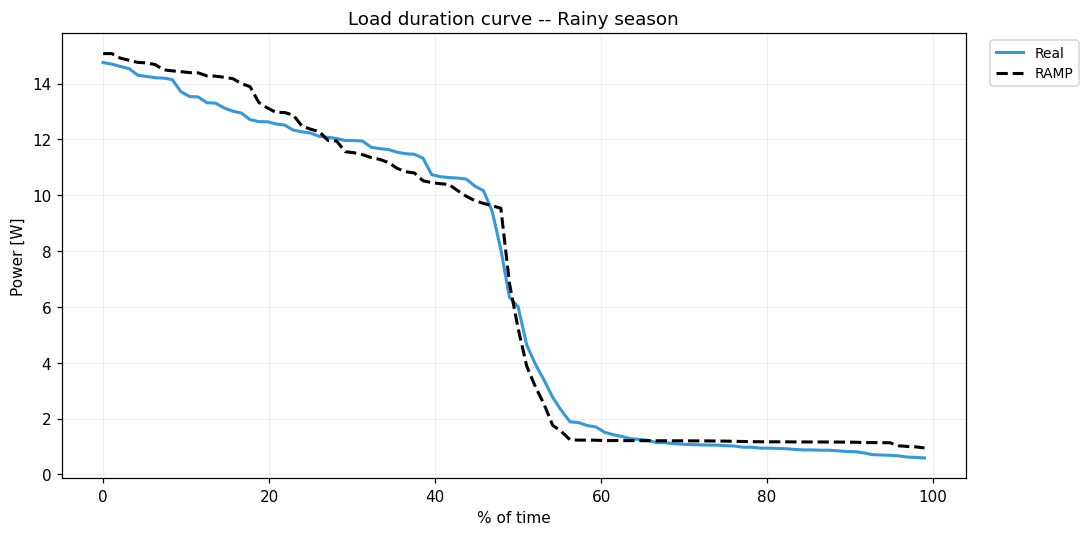

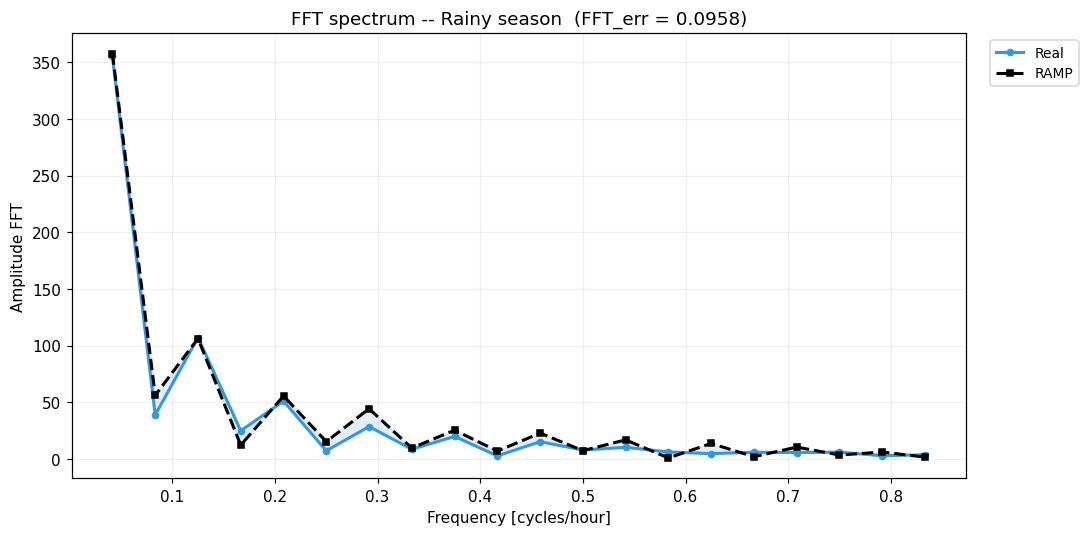

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
2,Rainy season,6,0.068,0.037,0.096,1.433,2.195,-0.003


In [9]:
season = "Rainy season"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_Rainy_season.png", f"41_ldc_Rainy_season.png", f"42_fft_Rainy_season.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## October

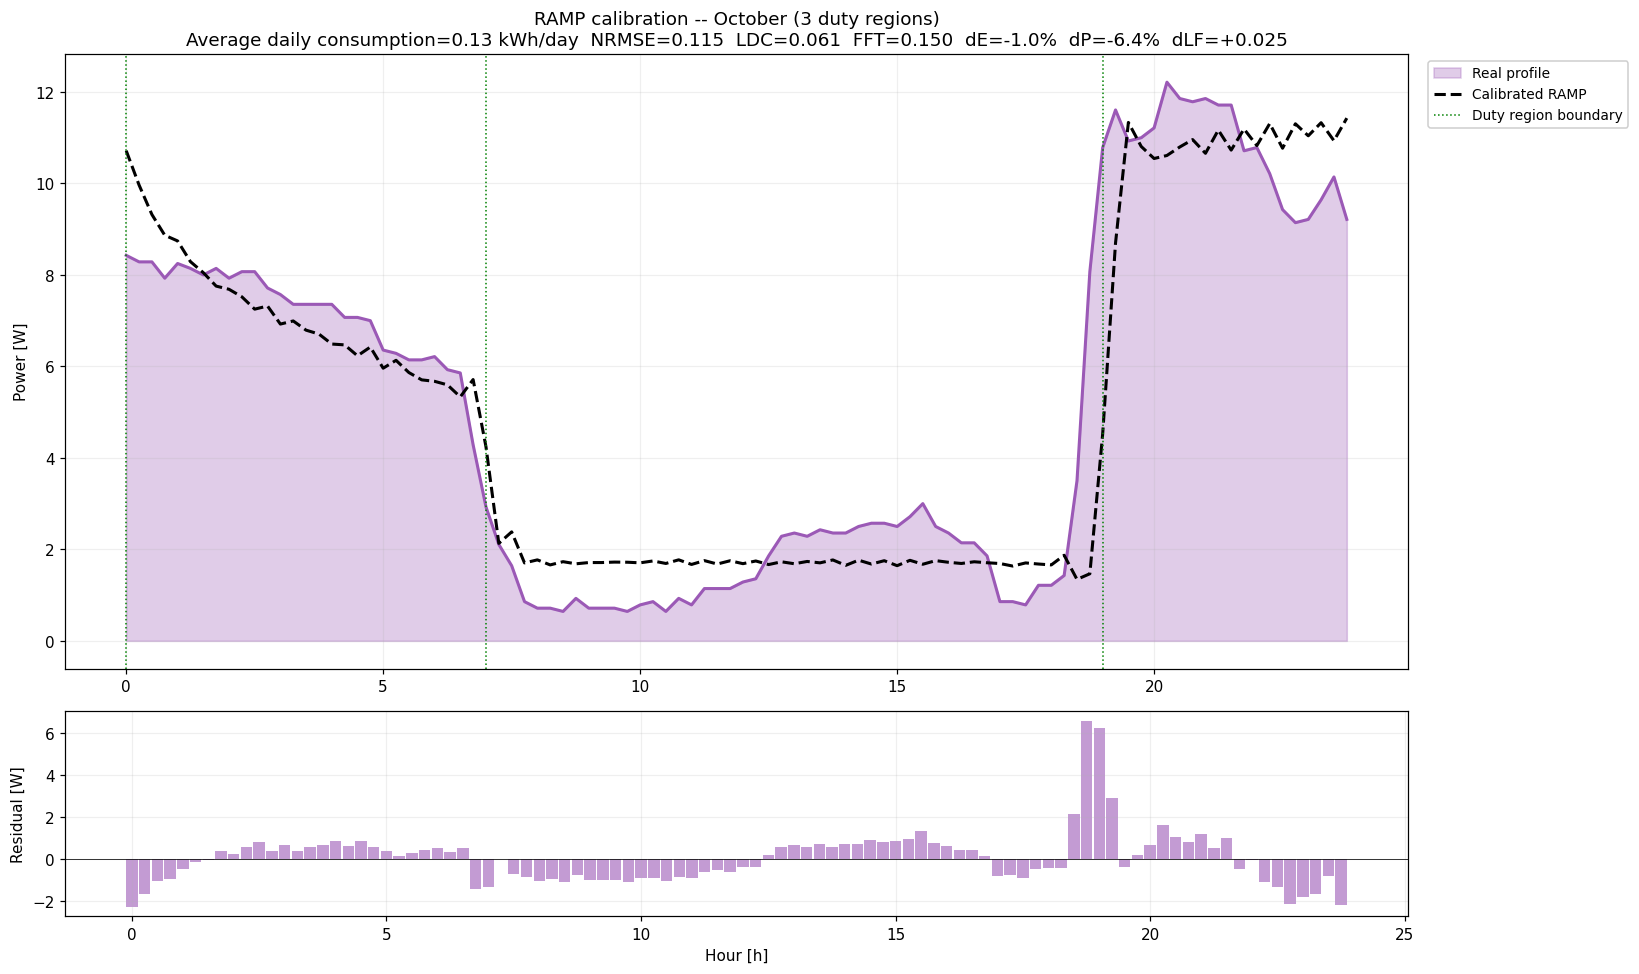

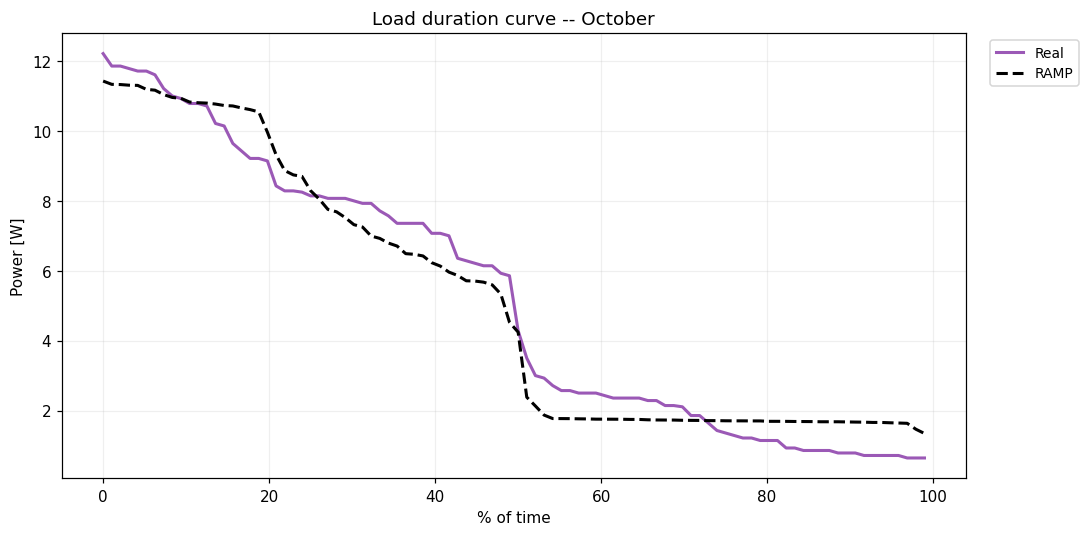

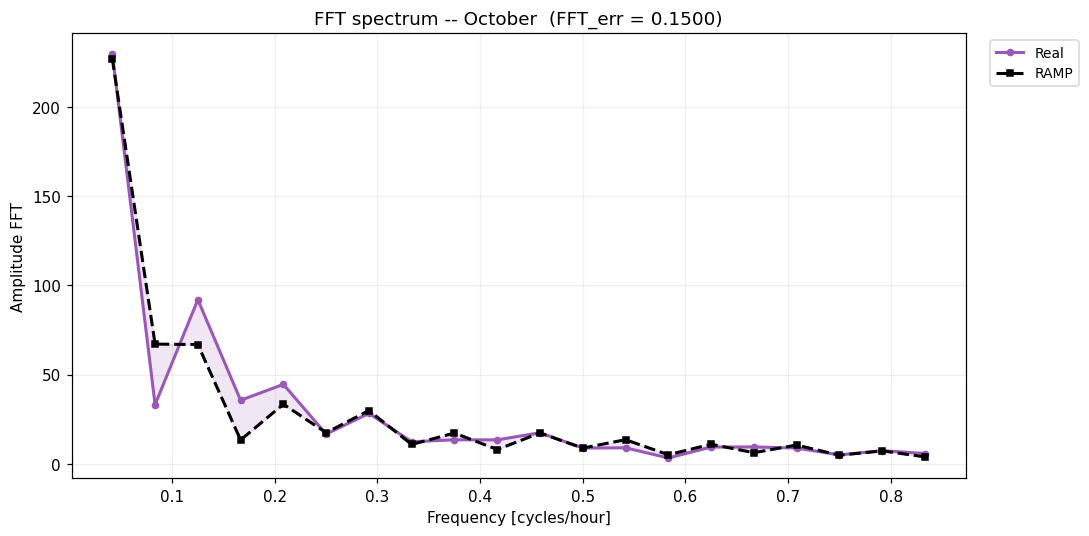

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
3,October,4,0.115,0.061,0.15,-1.035,-6.437,0.025


In [10]:
season = "October"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_October.png", f"41_ldc_October.png", f"42_fft_October.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## Calibrated RAMP parameters

,season,method_arm,p1_W,p2_W,n_regions,cycle_len_min,func_time_min,func_cycle_min,thermal_p_var,tfrv,...,region1_t_on_min,region1_t_off_min,region2_window,region2_duty,region2_t_on_min,region2_t_off_min,region3_window,region3_duty,region3_t_on_min,region3_t_off_min
0,Dry season,screened,134.6,0.53,3,100,1440,100,0.1,0.00,...,9,91,420-1140,0.020,2,98,1140-1440,0.118,12,88
1,May,classic,42.0,0.47,3,74,1440,74,0.1,0.00,...,18,56,420-1140,0.027,2,72,1140-1440,0.410,30,44
2,Rainy season,classic,32.0,0.53,3,65,1440,65,0.1,0.95,...,23,42,420-1140,0.031,2,63,1140-1440,0.534,35,30
3,October,classic,25.2,0.58,3,32,1440,32,0.1,0.00,...,7,25,420-1140,0.062,2,30,1140-1440,0.481,15,17


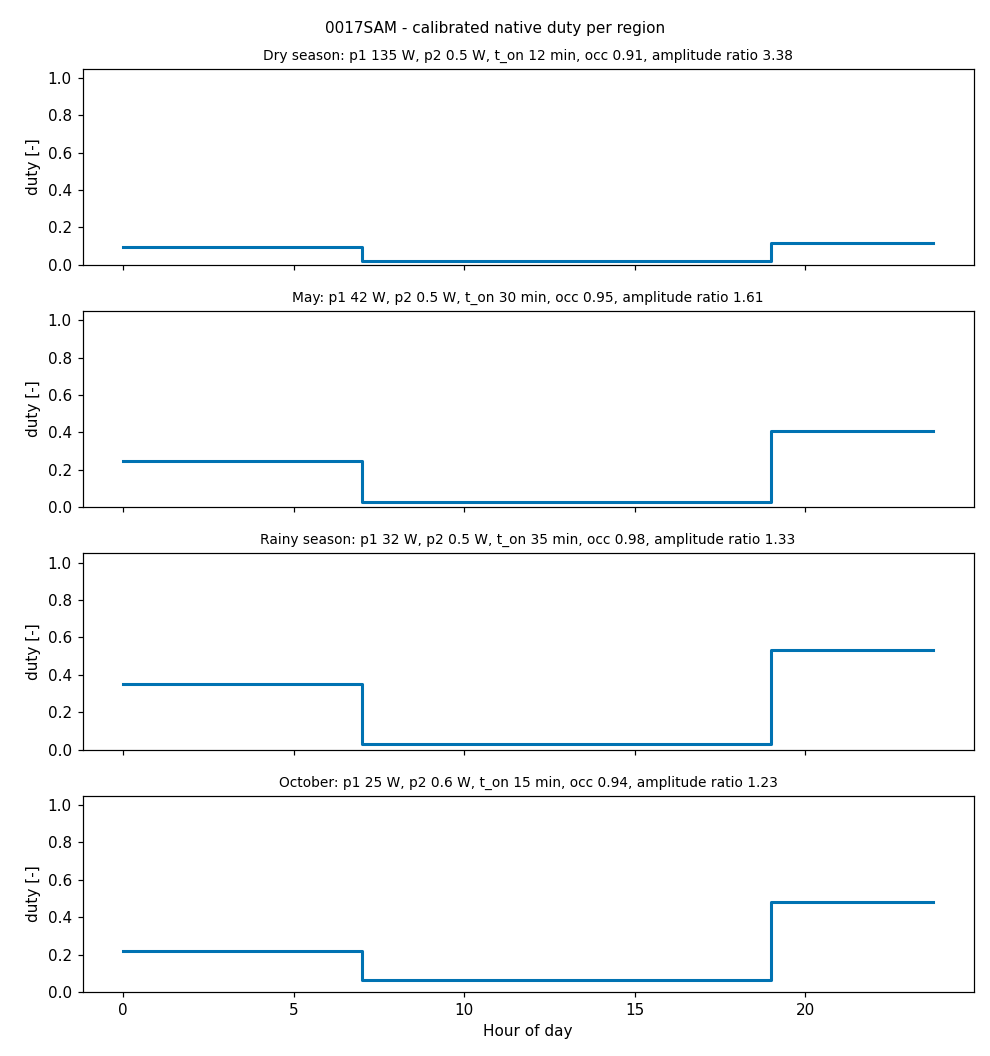

In [11]:
params = pd.read_csv(RESULTS / "appliance_parameters.csv")
display(params.round(3))
show("50_param_summary.png")